# Imports der Bibliotheken

In [1]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [2]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/load_profile.csv', index_col=0)
input_data

,electricity,PV,temp,heat_water,heat_space
index,,,,,
0,0.343,0.000,-2.620,0.029,2.272
1,0.102,0.000,-3.313,0.036,2.336
2,0.185,0.000,-3.869,0.029,2.416
3,0.199,0.000,-4.301,0.053,2.576
4,0.297,0.000,-4.747,0.127,2.976
...,...,...,...,...,...
163,0.840,0.039,13.508,0.338,2.752
164,0.676,0.000,11.191,0.350,2.608
165,0.509,0.000,10.786,0.300,2.288


<Axes: xlabel='index'>

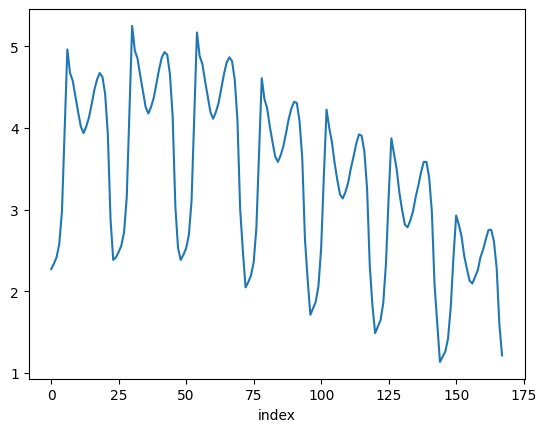

In [3]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot()

<Axes: xlabel='index'>

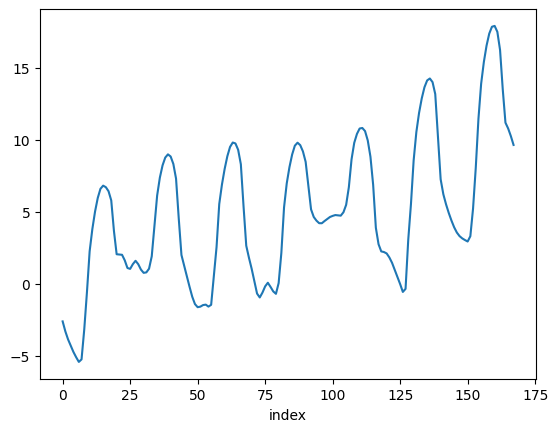

In [4]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot()

<Axes: xlabel='index'>

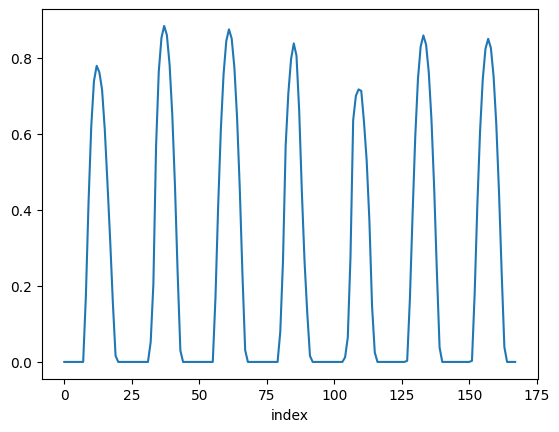

In [5]:
#Strahlung
solarthermie_strahlung = input_data["PV"]
solarthermie_strahlung.plot()

# System Eigenschaften

In [6]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
V_layer = (Store_height * Store_base) / 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = np.inf #kW Hausanschluss Leistung

In [7]:
V_layer

0.5333333333333333

<Axes: xlabel='index'>

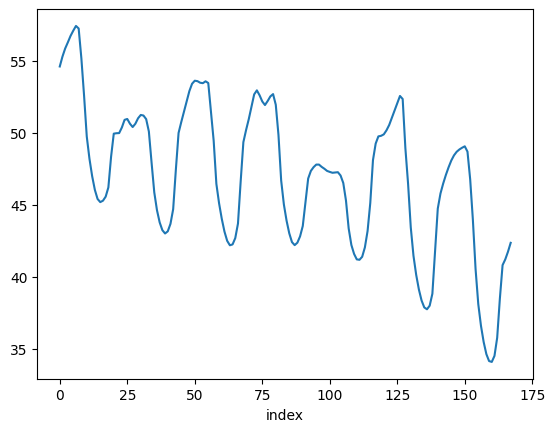

In [8]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot()

In [9]:
# Berechnung der Rücklauftemperatur

t_flow_return = T_flow - 10
t_flow_return

index
0      44.62
1      45.31
2      45.87
3      46.30
4      46.75
       ...  
163    28.49
164    30.81
165    31.21
166    31.74
167    32.36
Name: T_flow, Length: 168, dtype: float64

# Modellerstellung

In [10]:
# Aufbau des Modells
n = ph.HeatNetwork()
n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last',
      #p_set = power_demand_hp
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = input_data['heat_space'],
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='temperature',  # konstante Temperatur in den Schichten
      height=Store_height,
      base=Store_base,      
      cyclic=False,
      U_wall=0,
      V_initial = [V_layer, V_layer, V_layer],  # Volumen in den Schichten m³                 
      T_layer = [65,50,45],  # Beispieltemperaturen für die Schichten
      T_return = t_flow_return # Rücklauftemperatur des Heizsystems, °C
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power,
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_max = 65,        # max. lieferbare Temperatur der WP
      #T_sink = T_at_0,  
      heat_source = 'air'
)

#Hinzufügen der Warmwasserlast
# n.add('HeatLoad',
#       name = 'heat_water_demand',
#       heat_store = 'hs',
#       p_set = input_data['DE_heat_profile_water_SFH']/1000,
#       T_demand = T_Warmwasser
#       )

In [11]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [12]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [168 rows x 0 columns],
 'T_return': HeatStore     hs
 snapshot        
 0          44.62
 1          45.31
 2          45.87
 3          46.30
 4          46.75
 ...          ...
 163        28.49
 164        30.81
 165        31.21
 166        31.74
 167        32.36
 
 [168 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,

In [ ]:
# Optimierung mit rollierendem Horizont
#Langfristig 3 Woche Modellierung
n.optimize.optimize_with_rolling_horizon(horizon = 24, overlap = 12)

INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [0:23] (1/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.03s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-d8quirxv.lp
Reading time = 0.01 seconds
obj: 576 rows, 240 columns, 1013 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 576 rows, 240 columns and 1013 nonzeros
Model fingerprint: 0xfc194f13
Coefficient statistics:
  Matrix range     [3e-01, 3e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-01, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 485 rows and 96 columns
Presolve time: 0.01s
Presolved: 91 rows, 144 columns, 394 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.613708e+01   0.000000e+00      0s
 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 576 duals
Objective: 1.04e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [12:35] (2/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


...

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 576 duals
Objective: 4.05e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [156:167] (14/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.02s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-jp9khj15.lp
Reading time = 0.02 seconds
obj: 288 rows, 120 columns, 513 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 288 rows, 120 columns and 513 nonzeros
Model fingerprint: 0xe215297b
Coefficient statistics:
  Matrix range     [3e-01, 5e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 234 rows and 31 columns
Presolve time: 0.00s
Presolved: 54 rows, 89 columns, 232 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.594698e-02   0.000000e+00      0s
    

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 120 primals, 288 duals
Objective: 2.12e-03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


In [14]:
#Zuordnung der Ergebnisse
m = n.optimize.create_model()

Index(['electricity'], dtype='object', name='Bus')


In [15]:
#Inhalte der Optimierung
m

Linopy MILP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * HeatStore-hs-V_layer (snapshot, layer)
 * HeatStore-hs-p_internal (snapshot, layer)
 * HeatPump-status (snapshot, HeatPump)
 * HeatPump-hp-p (snapshot, layer)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * HeatStore-hs-fix-volume-upper (snapshot)
 * HeatStore-hs-fix-volume-lower (snapshot, layer)
 * HeatStore-hs-fix-layer-upper (snapshot, layer)
 * HeatStore-hs-layer_balance (snapshot, layer)
 * HeatStore-hs-internal-lower (snapshot, layer)
 * HeatPump-hp-fix-p-lower (snapshot)
 * HeatPump-hp-fix-p-upper (snapshot)
 * HeatPump-hp-fix-p-layer-lower (snapshot, layer)
 * HeatPump-hp-fix-p-layer-upper (snapshot, layer)

Status:
-------
initialized

In [16]:
n.heat_pumps_t

{'T_source':               hp
 snapshot        
 0         -2.620
 1         -3.313
 2         -3.869
 3         -4.301
 4         -4.747
 ...          ...
 163       13.508
 164       11.191
 165       10.786
 166       10.258
 167        9.643
 
 [168 rows x 1 columns],
 'T_nom': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [168 rows x 0 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 

In [17]:
heatstore_daten=n.heat_stores_t.T

In [18]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [168 rows x 0 columns],
 'T_return': HeatStore     hs
 snapshot        
 0          44.62
 1          45.31
 2          45.87
 3          46.30
 4          46.75
 ...          ...
 163        28.49
 164        30.81
 165        31.21
 166        31.74
 167        32.36
 
 [168 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,

# Python Ergebnisse

In [19]:
v_hs_65 = n.heat_stores_t.V.iloc[:, 0]
v_hs_50 = n.heat_stores_t.V.iloc[:, 1]
v_hs_45 = n.heat_stores_t.V.iloc[:, 2]
T_return = n.heat_stores_t.T_return

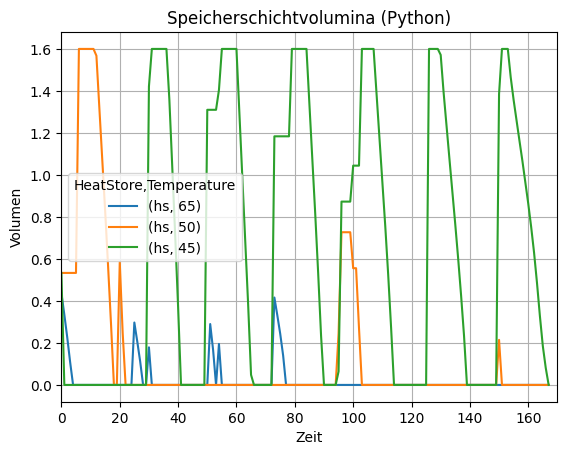

In [20]:
n.heat_stores_t.V.plot()
plt.title('Speicherschichtvolumina (Python)')
plt.xlabel('Zeit')
plt.ylabel('Volumen')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/py_speicherschichten.png')
plt.show()


In [21]:
n.heat_pumps_t

{'T_source':               hp
 snapshot        
 0         -2.620
 1         -3.313
 2         -3.869
 3         -4.301
 4         -4.747
 ...          ...
 163       13.508
 164       11.191
 165       10.786
 166       10.258
 167        9.643
 
 [168 rows x 1 columns],
 'T_nom': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [168 rows x 0 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 

In [22]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten 
p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
COP = n.heat_pumps_t.COP


In [23]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 68.95 €


# TRNSYS Ergebnisse

In [24]:
TRNSYSinputs = [
    "Inputs/TRNSYS/TRNSYSMassenstromHausseitig.csv",
    "Inputs/TRNSYS/TRNSYSRaumwärmebedarf.csv",
    "Inputs/TRNSYS/TRNSYSRücklauftemperaturKonstanterTemperaturspeicher.csv",
    "Inputs/TRNSYS/TRNSYSspeichermitteltemperaturKonstanterTemperaturspeicher.csv",
    #"Inputs/TRNSYS/TRNSYSspeicherschichttemperaturen.csv",
    "Inputs/TRNSYS/TRNSYSWärmepumpe.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata = TRNSYSdata.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata = TRNSYSdata.round(6)
TRNSYSdata

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_P_heat,ts_m_flow
0,2112.0,195.627840,-2.620,2.272,49.885,30.000000,11.766,700.0
1,2113.0,201.138484,-3.313,2.336,52.173,58.109656,8.448,700.0
2,2114.0,208.026788,-3.869,2.416,50.730,56.255813,0.000,0.0
3,2115.0,221.803396,-4.301,2.576,52.612,59.800088,7.062,700.0
4,2116.0,256.244917,-4.747,2.976,51.111,57.578383,0.000,0.0
...,...,...,...,...,...,...,...,...
163,2275.0,236.957666,13.508,2.752,36.732,40.142000,0.000,0.0
164,2276.0,224.558718,11.191,2.608,35.263,39.253237,0.000,0.0
165,2277.0,197.005501,10.786,2.288,34.001,38.328127,0.000,0.0
166,2278.0,137.766085,10.258,1.600,33.126,37.606006,0.000,0.0


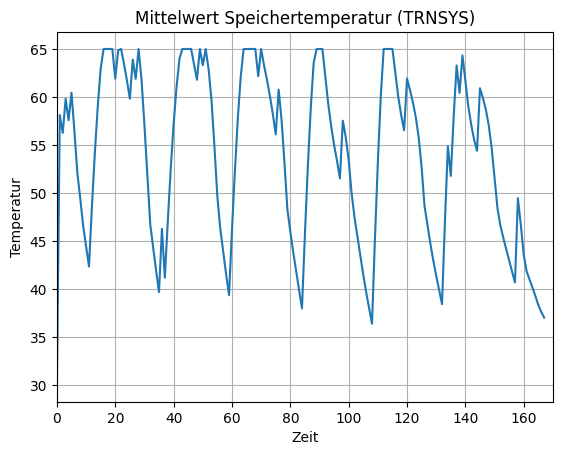

In [25]:
TRNSYS_T_m = TRNSYSdata['ts_T_m'].copy()

TRNSYS_T_m.plot()
plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/ts_speicherschichten_m.png')
plt.show()

# CSV-Ausgabe

In [26]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.values.flatten(),
    'py_P_heat_65': p_heat[('hp', 65)].values.flatten(),
    'py_P_heat_50': p_heat[('hp', 50)].values.flatten(),
    'py_P_heat_45': p_heat[('hp', 45)].values.flatten(),
    'py_COP_65': COP[('hp', 65)].values.flatten(),
    'py_COP_50': COP[('hp', 50)].values.flatten(),
    'py_COP_45': COP[('hp', 45)].values.flatten(),
    'py_V_65': v_hs_65.values.flatten(),
    'py_V_50': v_hs_50.values.flatten(),
    'py_V_45': v_hs_45.values.flatten(),
    'py_V_total':  v_hs_65.values.flatten() + v_hs_50.values.flatten() + v_hs_45.values.flatten(),
    'py_T_return': T_return.values.flatten(),
    'py_P_heat_total': p_heat[('hp', 65)].values.flatten() + p_heat[('hp', 50)].values.flatten() + p_heat[('hp', 45)].values.flatten()
})
output_pypsa = output_pypsa.round(6)

output_pypsa.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_pypsa.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)

In [27]:
output_combined = pd.concat([output_pypsa, TRNSYSdata], axis=1)
output_combined

,py_P_elec,py_P_heat_65,py_P_heat_50,py_P_heat_45,py_COP_65,py_COP_50,py_COP_45,py_V_65,py_V_50,py_V_45,...,py_T_return,py_P_heat_total,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_P_heat,ts_m_flow
0,0.000000,0.000000,0.0,0.00000,1.51,2.19,2.48,0.437343,0.533333,0.533333,...,44.62,0.000000,2112.0,195.627840,-2.620,2.272,49.885,30.000000,11.766,700.0
1,0.000000,0.000000,0.0,0.00000,1.48,2.15,2.43,0.335191,0.533333,0.000000,...,45.31,0.000000,2113.0,201.138484,-3.313,2.336,52.173,58.109656,8.448,700.0
2,0.000000,0.000000,0.0,0.00000,1.46,2.12,2.40,0.226447,0.533333,0.000000,...,45.87,0.000000,2114.0,208.026788,-3.869,2.416,50.730,56.255813,0.000,0.0
3,0.000000,0.000000,0.0,0.00000,1.45,2.10,2.38,0.107835,0.533333,0.000000,...,46.30,0.000000,2115.0,221.803396,-4.301,2.576,52.612,59.800088,7.062,700.0
4,0.479438,0.690391,0.0,0.00000,1.44,2.07,2.35,0.000000,0.533333,0.000000,...,46.75,0.690391,2116.0,256.244917,-4.747,2.976,51.111,57.578383,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.000000,0.000000,0.0,0.00000,2.25,3.23,3.62,0.000000,0.000000,0.486471,...,28.49,0.000000,2275.0,236.957666,13.508,2.752,36.732,40.142000,0.000,0.0
164,0.000000,0.000000,0.0,0.00000,2.12,3.06,3.44,0.000000,0.000000,0.328220,...,30.81,0.000000,2276.0,224.558718,11.191,2.608,35.263,39.253237,0.000,0.0
165,0.000000,0.000000,0.0,0.00000,2.10,3.03,3.41,0.000000,0.000000,0.185359,...,31.21,0.000000,2277.0,197.005501,10.786,2.288,34.001,38.328127,0.000,0.0
166,0.000000,0.000000,0.0,0.00000,2.07,3.00,3.37,0.000000,0.000000,0.081463,...,31.74,0.000000,2278.0,137.766085,10.258,1.600,33.126,37.606006,0.000,0.0


In [28]:
output_combined_ordered = output_combined.iloc[:, [ 13, 17, 18, 19, 20, 16, 15, 14, 11,10,12, 0, 1, 4, 7, 2, 5, 8, 3, 6, 9]]
output_combined_ordered.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_combined_ordered.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,Time,ts_T_R,ts_T_m,ts_P_heat,ts_m_flow,ts_P_heatspace,ts_T_amb,ts_m_heatspace,py_T_return,py_V_total,...,py_P_elec,py_P_heat_65,py_COP_65,py_V_65,py_P_heat_50,py_COP_50,py_V_50,py_P_heat_45,py_COP_45,py_V_45
0,2112.0,49.885,30.000000,11.766,700.0,2.272,-2.620,195.627840,44.62,1.504010,...,0.000000,0.000000,1.51,0.437343,0.0,2.19,0.533333,0.00000,2.48,0.533333
1,2113.0,52.173,58.109656,8.448,700.0,2.336,-3.313,201.138484,45.31,0.868524,...,0.000000,0.000000,1.48,0.335191,0.0,2.15,0.533333,0.00000,2.43,0.000000
2,2114.0,50.730,56.255813,0.000,0.0,2.416,-3.869,208.026788,45.87,0.759780,...,0.000000,0.000000,1.46,0.226447,0.0,2.12,0.533333,0.00000,2.40,0.000000
3,2115.0,52.612,59.800088,7.062,700.0,2.576,-4.301,221.803396,46.30,0.641169,...,0.000000,0.000000,1.45,0.107835,0.0,2.10,0.533333,0.00000,2.38,0.000000
4,2116.0,51.111,57.578383,0.000,0.0,2.976,-4.747,256.244917,46.75,0.533333,...,0.479438,0.690391,1.44,0.000000,0.0,2.07,0.533333,0.00000,2.35,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2275.0,36.732,40.142000,0.000,0.0,2.752,13.508,236.957666,28.49,0.486471,...,0.000000,0.000000,2.25,0.000000,0.0,3.23,0.000000,0.00000,3.62,0.486471
164,2276.0,35.263,39.253237,0.000,0.0,2.608,11.191,224.558718,30.81,0.328220,...,0.000000,0.000000,2.12,0.000000,0.0,3.06,0.000000,0.00000,3.44,0.328220
165,2277.0,34.001,38.328127,0.000,0.0,2.288,10.786,197.005501,31.21,0.185359,...,0.000000,0.000000,2.10,0.000000,0.0,3.03,0.000000,0.00000,3.41,0.185359
166,2278.0,33.126,37.606006,0.000,0.0,1.600,10.258,137.766085,31.74,0.081463,...,0.000000,0.000000,2.07,0.000000,0.0,3.00,0.000000,0.00000,3.37,0.081463


# Combined Plots

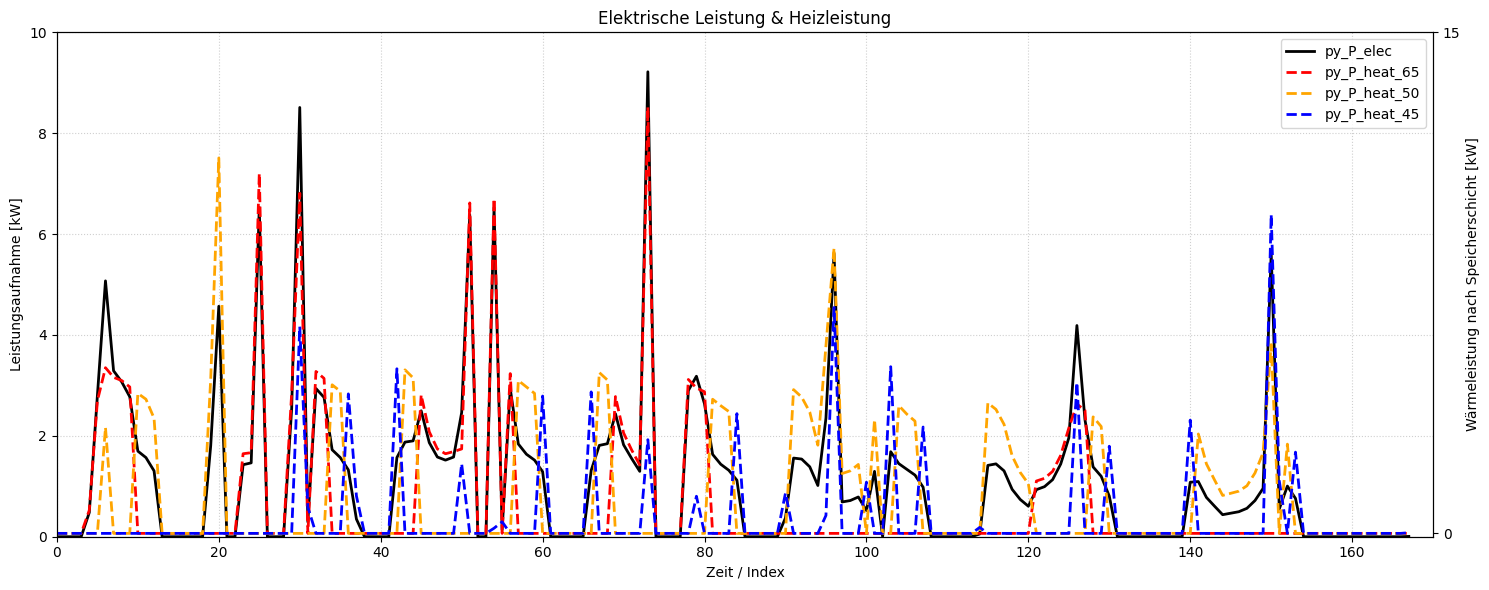

In [29]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_elec'], label='py_P_elec', linewidth=2, color='black')
#ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Elektrische Leistung & Heizleistung')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Leistungsaufnahme [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0, 10) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_65'], label='py_P_heat_65', linewidth=2, color='red', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_50'], label='py_P_heat_50', linewidth=2, color='orange', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_45'], label='py_P_heat_45', linewidth=2, color='blue', linestyle='--')

ax2.set_ylabel('Wärmeleistung nach Speicherschicht [kW]')
ax2.set_ylim(-0.1, 1.1) # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 15])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Elektrische Leistung & Heizleistung.png')
plt.show()

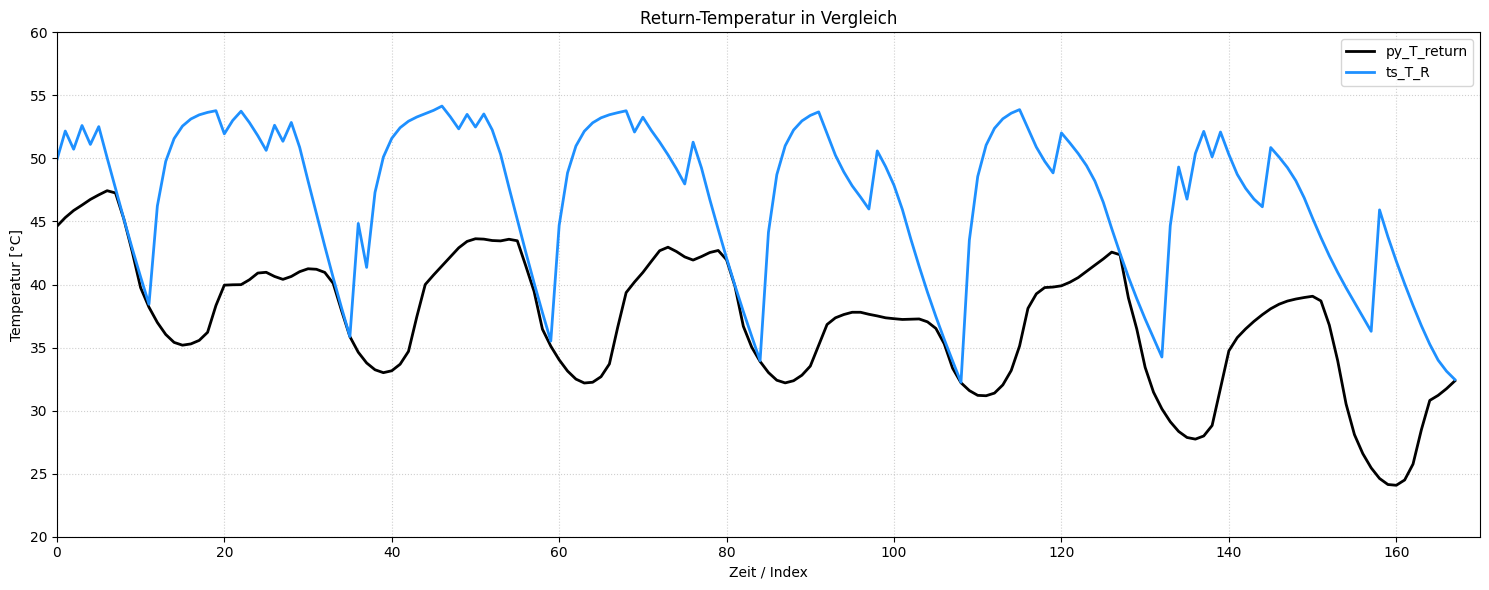

In [30]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_T_return'], label='py_T_return', linewidth=2, color='black')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_R'], label='ts_T_R', linewidth=2, color='dodgerblue')

ax1.set_title('Return-Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur [°C]')
ax1.set_xlim(0, 170)
ax1.set_ylim(20,60) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Rücklauftemperatur im Vergleich.png')
plt.show()

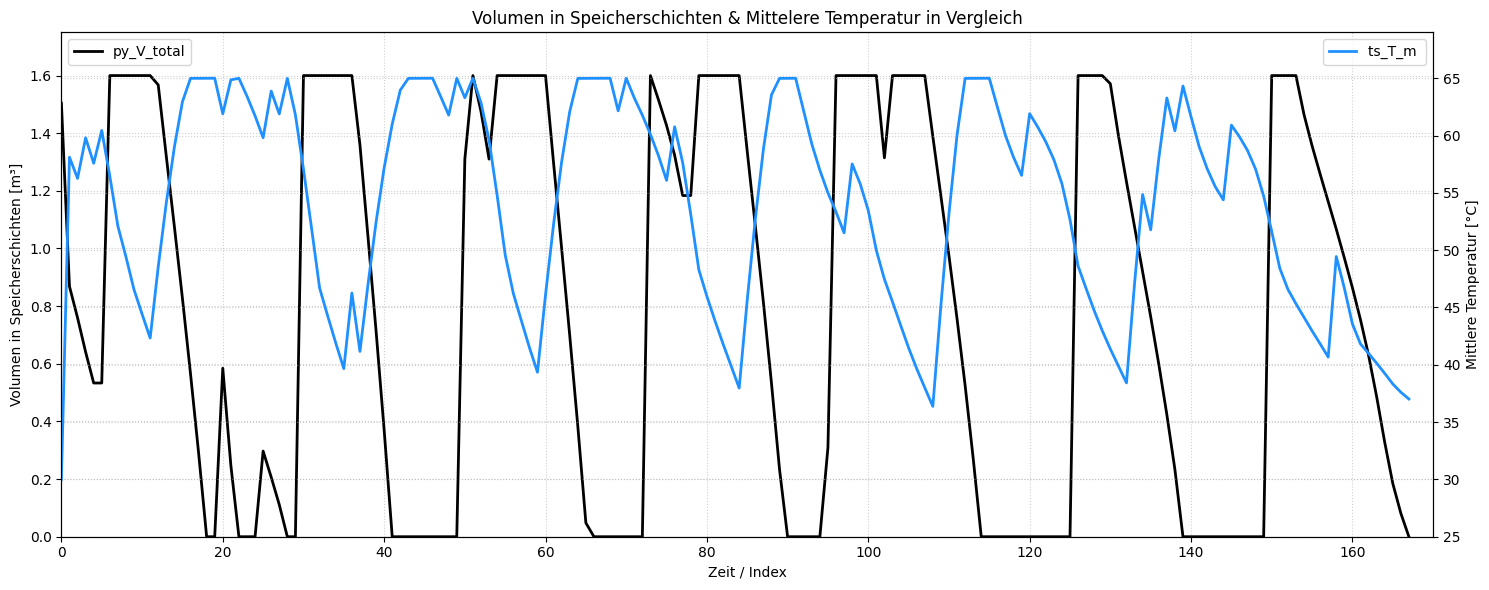

In [31]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_V_total'], label='py_V_total', linewidth=2, color='black')

ax1.set_title('Volumen in Speicherschichten & Mittelere Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Volumen in Speicherschichten [m³]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,1.75) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: Temperaturen ---
ax2 = ax1.twinx()
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='ts_T_m ', linewidth=2, color='dodgerblue')

ax2.set_xlabel('Zeit / Index')
ax2.set_ylabel('Mittlere Temperatur [°C]')
ax2.set_xlim(0, 170)
ax2.set_ylim(25,69) # Beispielhafter Bereich für Temperaturen
ax2.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper left')
ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Volumen und Mittlere Temperatur im Vergleich.png')
plt.show()

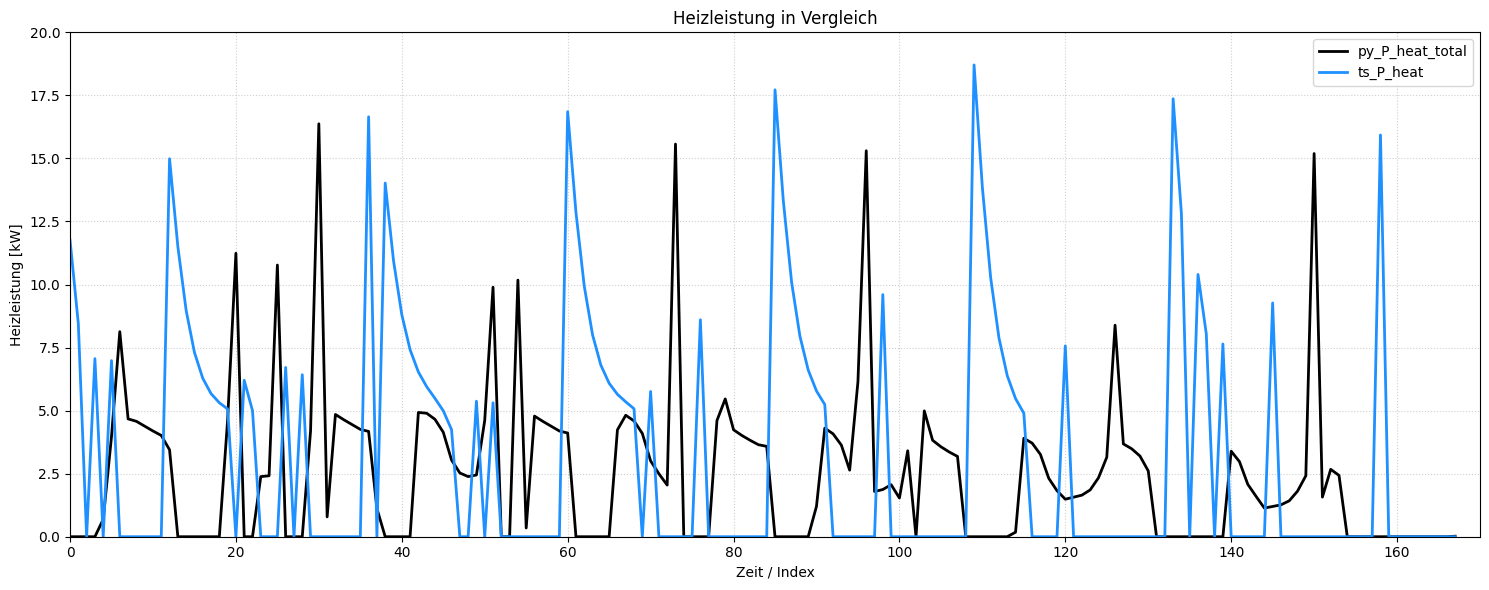

In [32]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_heat_total'], label='py_P_heat_total', linewidth=2, color='black')
ax1.plot(output_pypsa.index,output_combined_ordered['ts_P_heat'], label='ts_P_heat', linewidth=2, color='dodgerblue')

ax1.set_title('Heizleistung in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Heizleistung in Vergleich.png')

plt.show()

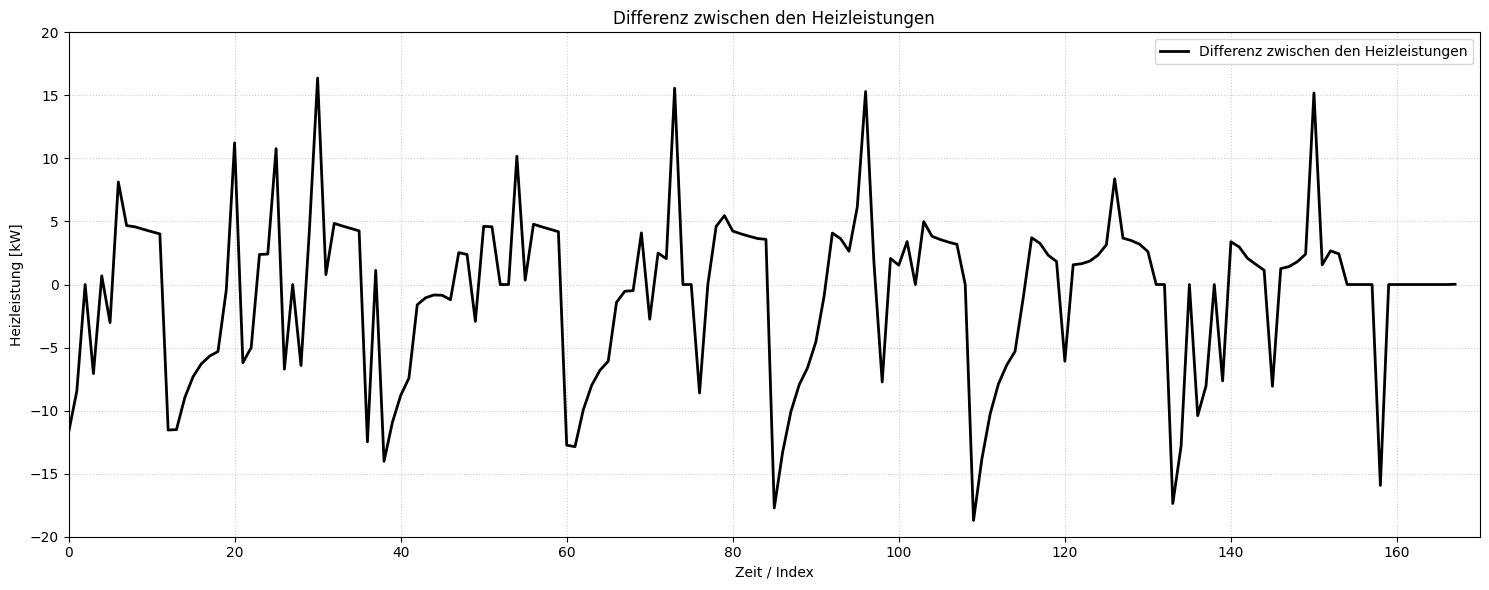

In [33]:
# Erstelle Figur und Achsen
from numpy import test


fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot((output_combined_ordered['py_P_heat_total'] - output_combined_ordered['ts_P_heat']), label='Differenz zwischen den Heizleistungen', linewidth=2, color='black')


ax1.set_title('Differenz zwischen den Heizleistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(-20,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Differenz zwischen den Heizleistungen.png')
plt.show()

KeyError: 'py_T_m'

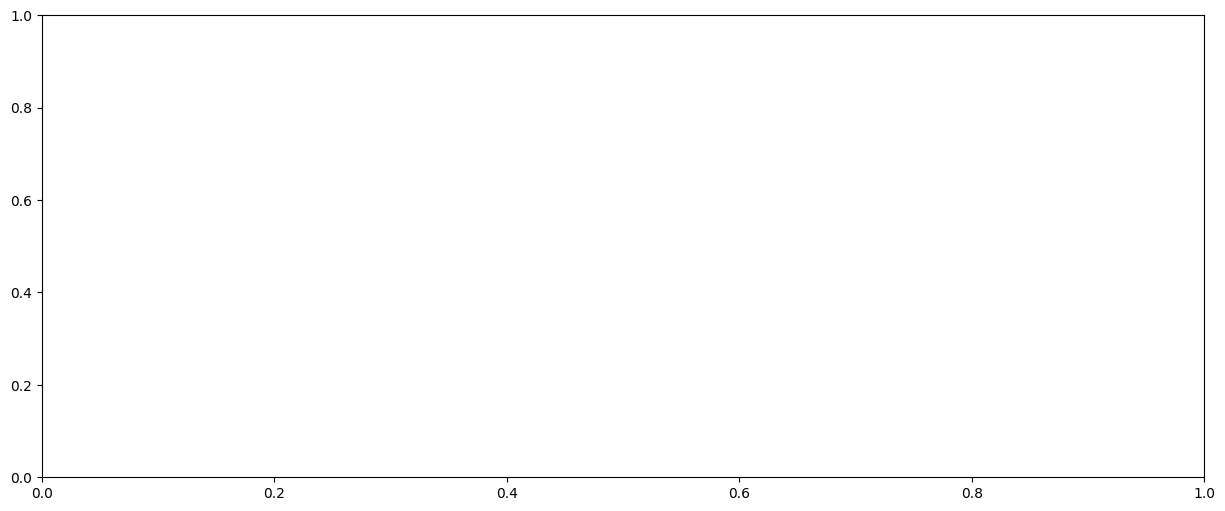

In [34]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata.columns:
    ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/vergleich_T_m+p_heat.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5)

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)
ax1.legend() # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.show()


In [ ]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Temperatur T1 (°C)')
ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.grid(True)
ax1.legend(loc='upper right')

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5, color='orange')
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--', color='red')
ax2.set_ylabel('Temperatur T2 (°C)')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5, color='green')
ax3.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--', color='brown')
ax3.set_ylabel('Temperatur T3 (°C)')
ax3.set_xlabel('Zeit / Index')
ax3.set_xlim(0, 170)
ax3.grid(True)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(15, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='Δ T1')
ax.plot(output_pypsa.index, delta_T_2, label='Δ T2')
ax.plot(output_pypsa.index, delta_T_3, label='Δ T3')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperaturdifferenzen: Python - TRNSYS')
ax.set_xlabel('Zeit / Index')
ax.set_ylabel('Abweichung [K]')
ax.set_xlim(0, 170)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata['ts_T_m']

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 170)
plt.tight_layout()
plt.show()

In [ ]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
delta_T_m.sum()